In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [6]:
df=pd.read_csv("Website.csv")

In [7]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3183 entries, 0 to 3182
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   # ----------------------------------------  3183 non-null   object
 1   Unnamed: 1                                  3183 non-null   object
 2   Unnamed: 2                                  3183 non-null   object
 3   Unnamed: 3                                  3183 non-null   object
 4   Unnamed: 4                                  3183 non-null   object
 5   Unnamed: 5                                  3183 non-null   object
 6   Unnamed: 6                                  3183 non-null   object
 7   Unnamed: 7                                  3183 non-null   object
 8   Unnamed: 8                                  3183 non-null   object
 9   Unnamed: 9                                  3183 non-null   object
dtypes: object(10)
memory usa

**Here the column name is not accuate also the datatype of the column is also not accurate.**

# Assigning the appropriate column name.

In [9]:
df.columns=df.iloc[0]
df=df.drop(index=0).reset_index(drop=True)
df.columns=["channel group","Date-hour", "Users","Sessions","Engaged_sessions",	"Average engagement time per session","Engaged sessions per user","Events per session","Engagement rate","Event count"]

In [10]:
df.head()

,channel group,Date-hour,Users,Sessions,Engaged_sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


**Here we assign 0th row as the columes and reset the index position.**

# Assigning the appropriate column Datatype.

In [11]:
df["Date-hour"]=pd.to_datetime(df["Date-hour"],format="%Y%M%d%H")

In [12]:
numeric_column=df.columns.drop(["channel group","Date-hour"])
df[numeric_column]=df[numeric_column].apply(pd.to_numeric)

In [13]:
df["Hour"]=df["Date-hour"].dt.hour

**Here we created new column "hour" by the help of "Date-hour" column .**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3182 non-null   object        
 1   Date-hour                            3182 non-null   datetime64[ns]
 2   Users                                3182 non-null   int64         
 3   Sessions                             3182 non-null   int64         
 4   Engaged_sessions                     3182 non-null   int64         
 5   Average engagement time per session  3182 non-null   float64       
 6   Engaged sessions per user            3182 non-null   float64       
 7   Events per session                   3182 non-null   float64       
 8   Engagement rate                      3182 non-null   float64       
 9   Event count                          3182 non-null   int64         
 10  Hour        

In [15]:
df.describe()

,Date-hour,Users,Sessions,Engaged_sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3182,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000,3182.000000
mean,2024-01-16 19:30:57.548711680,41.935889,51.192646,28.325581,66.644581,0.606450,4.675969,0.503396,242.272470,11.807040
min,2024-01-01 00:05:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-01-10 02:04:00,20.000000,24.000000,13.000000,32.103034,0.561404,3.750000,0.442902,103.000000,6.000000
50%,2024-01-17 01:04:00,42.000000,51.000000,27.000000,49.020202,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-01-24 00:04:00,60.000000,71.000000,41.000000,71.487069,0.750000,5.217690,0.633333,339.000000,18.000000
max,2024-01-30 23:04:00,237.000000,300.000000,144.000000,4525.000000,2.000000,56.000000,1.000000,1402.000000,23.000000
std,NaN,29.582258,36.919962,20.650569,127.200659,0.264023,2.795228,0.228206,184.440313,6.886686


In [16]:
df.isnull().sum()

channel group                          0
Date-hour                              0
Users                                  0
Sessions                               0
Engaged_sessions                       0
Average engagement time per session    0
Engaged sessions per user              0
Events per session                     0
Engagement rate                        0
Event count                            0
Hour                                   0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

**Now, the data is cleaned and ready for visualization.**

# 1] The session and user over time .

In [18]:
sns.set(style="darkgrid")

In [19]:
combine=df.groupby("Hour")[["Users","Sessions"]].sum()
combine.head(10)

,Users,Sessions
Hour,,
0,5864,8148
1,4011,5228
2,3167,3999
3,2531,3199
4,2234,2786
5,2093,2598
6,2551,3161
7,3176,3946
8,3855,4781


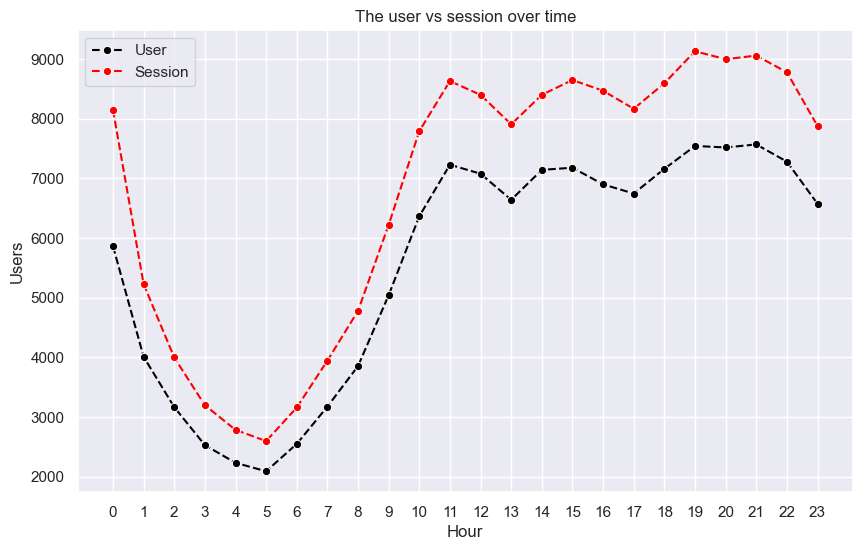

In [20]:
plt.figure(figsize=(10,6))
sns.lineplot(x="Hour",y="Users",data=combine,label="User",linestyle='--',color="black",marker="o")
sns.lineplot(x="Hour",y="Sessions",data=combine,label="Session",linestyle='--',color='red',marker="o")
plt.title("The user vs session over time")
plt.xticks(range(24))
plt.show()     

# Insights from Users vs Sessions by Hour Analysis

1. **Early Morning:** Both users and sessions decrease until around hour 5.

2. **Morning Growth:** Traffic rises sharply from around hour 6 to hour 11.

3. **Afternoon:** Traffic fluctuates but remains relatively high.

4. **Evening Peak:** Both metrics reach their highest levels around hours 19–21.

5. **Sessions Exceed Users:** The red line stays above the black line throughout the displayed hours.



# 2] which channel bought the highest users on the website.

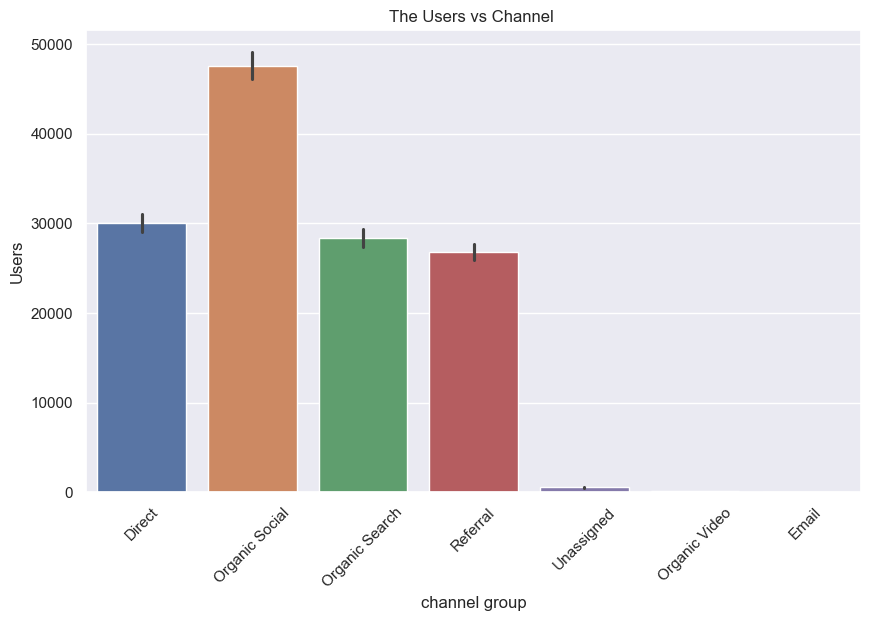

In [21]:
plt.figure(figsize=(10,6))
sns.barplot(x="channel group",y="Users",data=df,estimator=np.sum,palette="deep")
plt.title("The Users vs Channel ")
plt.xticks(rotation=45)
plt.show()

**The channel [Organic Social] bought the highest user on the website** 

# 3] Average engagement of user by channnel

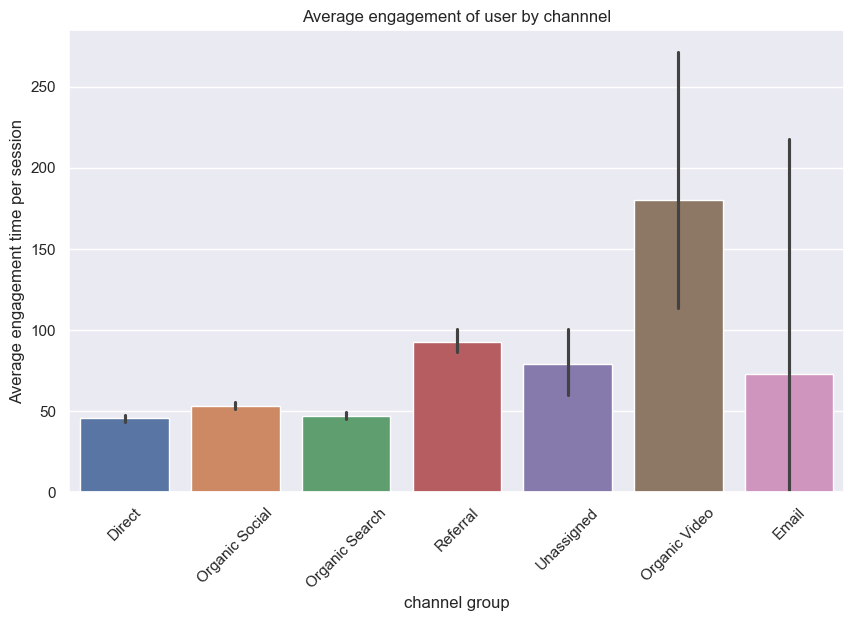

In [22]:
plt.figure(figsize=(10,6))
sns.set(style="darkgrid")
sns.barplot(data=df,x="channel group",y="Average engagement time per session",palette="deep")
plt.title("Average engagement of user by channnel")
plt.xticks(rotation=45)
plt.show()

## Insights from Channel Engagement

1. **Organic Search:** The Organic Search channel has the highest average time spent by users on the website, indicating strong user engagement.

2. **Email and Referral:** Email and Referral channels also show high user engagement. The company should focus on optimizing these channels to further improve user engagement and website performance.

# 4]Engagement rate according to the channel.

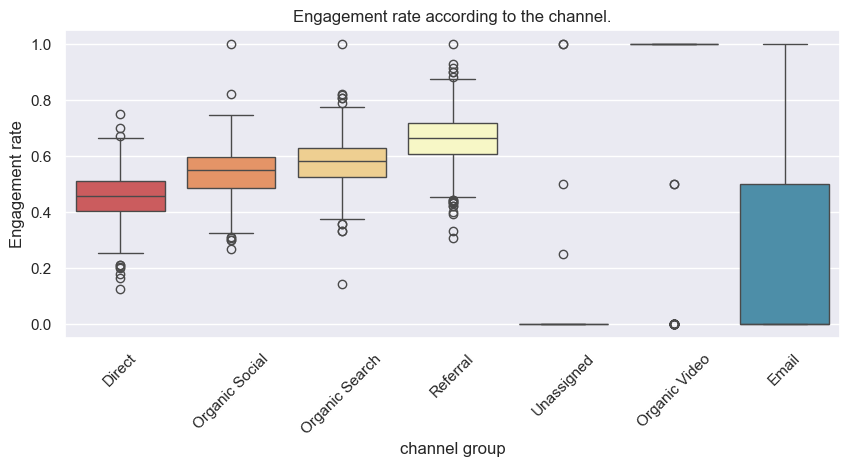

In [187]:
plt.figure(figsize=(10,4))
sns.set(style="darkgrid")
sns.boxplot(data=df,x="channel group",y="Engagement rate",palette="Spectral")
plt.title("Engagement rate according to the channel.")
plt.xticks(rotation=45)
plt.show()

## Insights from Engagement Rate by Channel

1. **Referral:** The Referral channel has a relatively high median engagement rate compared with most channels.

2. **Organic Search:** Organic Search shows a moderate-to-high engagement rate, with some outliers indicating unusually high or low values.

3. **Direct:** The Direct channel has a lower median engagement rate than Referral and Organic Search.

4. **Organic Social:** Organic Social shows a moderate engagement rate, with some high-engagement outliers.

5. **Email and Unassigned:** These channels show wide or unusual distributions, suggesting that the engagement data may be inconsistent or that the number of observations may be limited. Further investigation is needed.

# 5] Channel driving more engaged session compared to non-engaged ones.

In [24]:
df["non_Engaged_sessions"]=df["Sessions"]-df["Engaged_sessions"]

**Here we creted the new colummn "non_Engaged_sessions" .**

In [28]:
rate=df.groupby("channel group")[["Engaged_sessions","non_Engaged_sessions"]].sum().reset_index()
rate

,channel group,Engaged_sessions,non_Engaged_sessions
0,Direct,17243,19960
1,Email,1,2
2,Organic Search,19425,13947
3,Organic Social,32697,27930
4,Organic Video,109,32
5,Referral,20653,10337
6,Unassigned,4,555


In [37]:
rate_melted=rate.melt(id_vars="channel group",value_vars=["Engaged_sessions","non_Engaged_sessions"],var_name="session type",value_name="Sessions")
rate_melted


,channel group,session type,Sessions
0,Direct,Engaged_sessions,17243
1,Email,Engaged_sessions,1
2,Organic Search,Engaged_sessions,19425
3,Organic Social,Engaged_sessions,32697
4,Organic Video,Engaged_sessions,109
5,Referral,Engaged_sessions,20653
6,Unassigned,Engaged_sessions,4
7,Direct,non_Engaged_sessions,19960
8,Email,non_Engaged_sessions,2
9,Organic Search,non_Engaged_sessions,13947


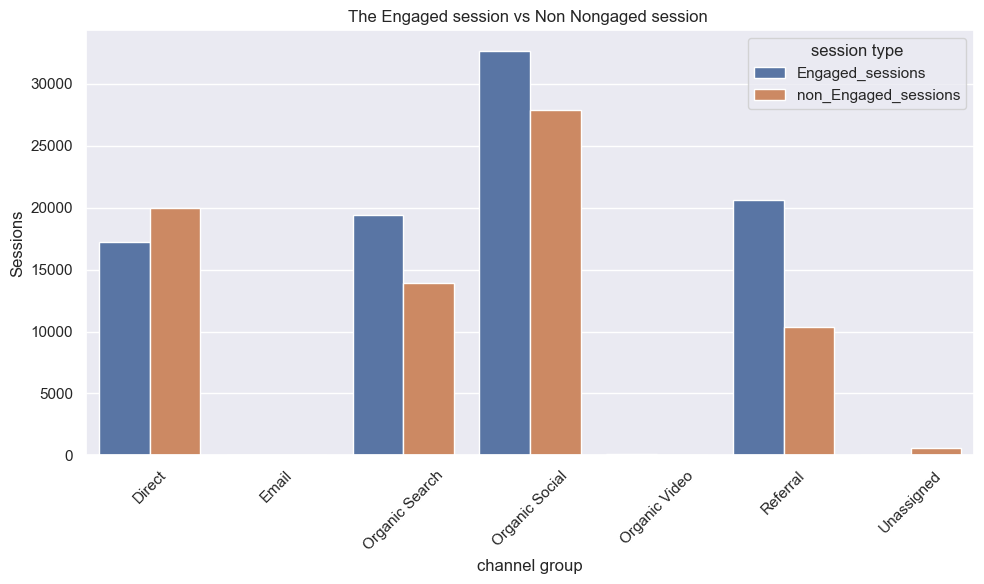

In [47]:
plt.figure(figsize=(10,6))
sns.set(style="darkgrid")
sns.barplot(data=rate_melted,x="channel group",y="Sessions",palette="deep",hue="session type")
plt.title("The Engaged session vs Non Nongaged session ")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Insights :

1. **Organic Social:** This channel records the highest number of both engaged and non-engaged sessions, indicating high traffic volume.

2. **Organic Search:** Engaged sessions exceed non-engaged sessions, suggesting relatively strong user engagement.

3. **Referral:** Engaged sessions are considerably higher than non-engaged sessions, indicating promising engagement performance.

4. **Direct:** Non-engaged sessions exceed engaged sessions, suggesting an opportunity to improve the quality of direct traffic.

5. **Email:** Email has very few sessions in this dataset, so more data may be needed before drawing conclusions.

# 6] The traffic by hour and channel.

In [94]:
heatmap_data=df.groupby(["channel group","Hour"])["Sessions"].sum().unstack().fillna(0)
heatmap_data.head(10)

Hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
channel group,,,,,,,,,,,,,,,,,,,,,
Direct,1684.0,1196.0,887.0,771.0,666.0,679.0,768.0,889.0,1078.0,1347.0,...,1803.0,1809.0,1802.0,1774.0,1937.0,2062.0,2062.0,2059.0,2149.0,2581.0
Email,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Organic Search,1311.0,984.0,804.0,606.0,535.0,506.0,639.0,778.0,938.0,1269.0,...,1964.0,1898.0,1709.0,1598.0,1844.0,1887.0,1924.0,1838.0,1814.0,1409.0
Organic Social,3917.0,2108.0,1537.0,1249.0,1081.0,951.0,1171.0,1524.0,1886.0,2390.0,...,2866.0,3250.0,3325.0,3188.0,3157.0,3469.0,3206.0,3323.0,3027.0,2566.0
Organic Video,6.0,5.0,2.0,2.0,2.0,1.0,1.0,2.0,4.0,4.0,...,7.0,8.0,9.0,6.0,6.0,12.0,10.0,11.0,12.0,2.0
Referral,1204.0,923.0,755.0,560.0,495.0,453.0,565.0,743.0,862.0,1192.0,...,1723.0,1644.0,1589.0,1575.0,1620.0,1660.0,1762.0,1799.0,1744.0,1298.0
Unassigned,26.0,12.0,13.0,11.0,6.0,8.0,17.0,10.0,13.0,19.0,...,36.0,38.0,33.0,24.0,29.0,38.0,32.0,26.0,31.0,20.0


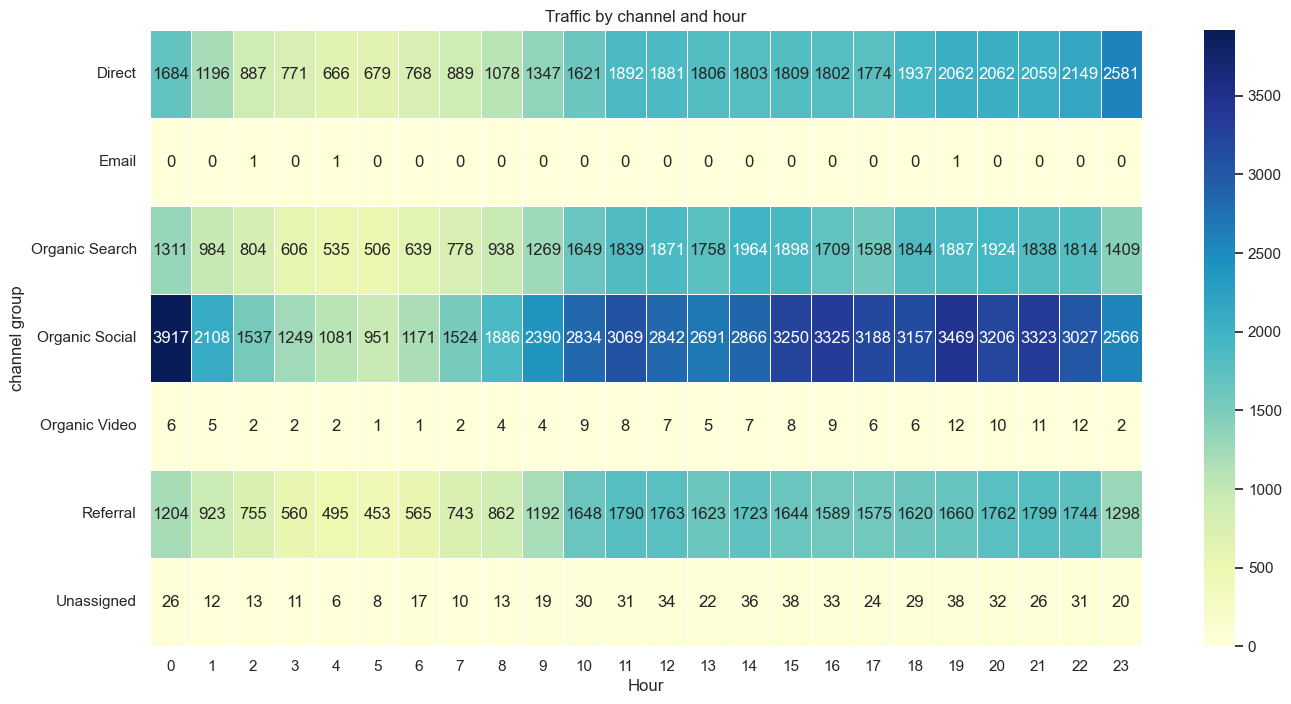

In [99]:
plt.figure(figsize=(16,8))
sns.set(style="darkgrid")
sns.heatmap(heatmap_data,cmap='YlGnBu',annot=True,linewidths=0.5,fmt=".0f")
plt.title("Traffic by channel and hour")
plt.show()

## Insights 

1. **Direct:** Traffic peaks at hour 23 (11 PM).

2. **Organic Search:** Traffic peaks at hour 14 (2 PM).

3. **Organic Social:** Traffic peaks at hour 0 (12 AM), with additional high-traffic periods during the afternoon and evening.

4. **Referral:** Traffic peaks at hour 11 (11 AM).

5. **Organic Video:** Traffic remains low throughout the day.

# 7] session vs Engagement rate over time.

In [112]:
combine=df.groupby("Date-hour")[["Sessions","Engagement rate"]].sum()
combine

,Sessions,Engagement rate
Date-hour,,
2024-01-01 00:05:00,277,1.803575
2024-01-01 01:05:00,175,2.187431
2024-01-01 02:05:00,129,1.923843
2024-01-01 03:05:00,109,2.004974
2024-01-01 04:05:00,112,2.276923
...,...,...
2024-01-30 19:04:00,363,2.234806
2024-01-30 20:04:00,346,2.461341
2024-01-30 21:04:00,324,2.207308


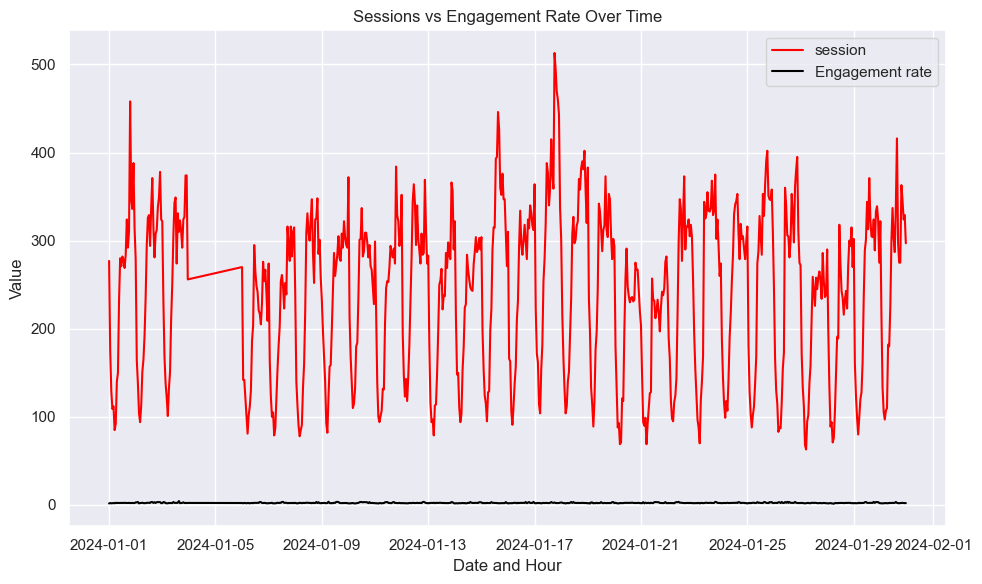

In [121]:
plt.figure(figsize=(10,6))
sns.set(style="darkgrid")
sns.lineplot(data=combine,x="Date-hour",y="Sessions",color="red",label='session')
sns.lineplot(data=combine,x="Date-hour",y="Engagement rate",color="black",label='Engagement rate')
plt.title("Sessions vs Engagement Rate Over Time")
plt.xlabel("Date and Hour")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

## Insights: 

1. **Fluctuating Traffic:** Website sessions fluctuate significantly throughout January 2024, with frequent increases and decreases.

2. **Traffic Peaks:** The highest session volume occurs around January 17, reaching approximately 510 sessions.

3. **Recurring Traffic Patterns:** Several sharp drops in session volume appear throughout the month, suggesting recurring hourly traffic patterns.

4. **Engagement Rate Stability:** The engagement rate appears relatively stable compared with the large fluctuations in session volume.

5. **Scale Difference:** The engagement-rate line appears almost flat because session counts are much larger numerically than engagement-rate values.

